# MIME-Type Drift Across Focus-Crawl Segments

**Research question:** Does the MIME-type composition of fetched records drift across the lifetime of the focus crawl `CC-SUPPLEMENTAL-2026-22`?

This notebook is a sibling of [`compare_classifier_scores_segment_drift.ipynb`](compare_classifier_scores_segment_drift.ipynb), which tracks the classifier *score* per segment. Here we track the *MIME mix* (a fair sample of what kinds of resources were actually fetched).

Source: CDX index files (`*.cdx.gz`) under `cc-focus-tools/data/CC-SUPPLEMENTAL-2026-22/segments/*/cdx/warc/`. We **never open the WARC payloads** &mdash; the MIME columns we need live in the CDX JSON blob already.

Outputs:

1. **Plot 1** &mdash; stacked bar of **absolute record counts** per segment (composition + segment size).
2. **Plot 2** &mdash; stacked bar of **normalized shares** per segment (composition only &mdash; the headline drift plot).

To keep re-runs fast we cache `(warc_filename, offset, mime_detected)` triples per CDX file under `data/cache/CC-SUPPLEMENTAL-2026-22/segments/…` (mirrors the source layout). The cache is rebuilt only when the target file is missing or `FORCE_REBUILD = True`.


In [1]:
from __future__ import annotations

import gzip
import json
import re
import time
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates  # noqa: F401  (kept for parity with sibling notebook; not used directly)
import matplotlib.pyplot as plt
import pandas as pd

FOCUS_NAME = "CC-SUPPLEMENTAL-2026-22"

# Repo-root-aware data path (works both from repo root and from notebooks/).
DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"

# CDX files live outside this repo &mdash; override here if your checkout differs.
CDX_ROOT = (
    Path("/Users/moc-malteos/repos/commoncrawl/cc-focus/cc-focus-tools/data")
    / FOCUS_NAME
    / "segments"
)
CACHE_ROOT = DATA_DIR / "cache" / FOCUS_NAME / "segments"

FORCE_REBUILD = False     # flip to True to rebuild the per-CDX cache
MIN_RECORDS = 100_000     # drop tiny / probe / aborted segments (real segments hold 1–3 M records)
TOP_N = 8                 # number of MIME types kept individually; rest → "other"

print(f"FOCUS_NAME : {FOCUS_NAME}")
print(f"CDX_ROOT   : {CDX_ROOT}  (exists={CDX_ROOT.exists()})")
print(f"CACHE_ROOT : {CACHE_ROOT}  (exists={CACHE_ROOT.exists()})")


FOCUS_NAME : CC-SUPPLEMENTAL-2026-22
CDX_ROOT   : /Users/moc-malteos/repos/commoncrawl/cc-focus/cc-focus-tools/data/CC-SUPPLEMENTAL-2026-22/segments  (exists=True)
CACHE_ROOT : ../data/cache/CC-SUPPLEMENTAL-2026-22/segments  (exists=True)


## 1. Discover crawl segments

Each segment directory under `CDX_ROOT` is named `<YYYYMMDDHHMMSS>` &mdash; the fetch start time. We pick those up by regex, parse them to `datetime`, and sort oldest-first.


In [2]:
SEGMENT_DIR_RE = re.compile(r"^\d{14}$")

segments: list[tuple[datetime, Path]] = []
for d in sorted(CDX_ROOT.iterdir()):
    if d.is_dir() and SEGMENT_DIR_RE.match(d.name):
        dt = datetime.strptime(d.name, "%Y%m%d%H%M%S")
        segments.append((dt, d))

if not segments:
    raise RuntimeError(f"No segment directories matching ^\\d{{14}}$ under {CDX_ROOT}")

print(f"Found {len(segments)} segments:")
for dt, d in segments:
    n_cdx = sum(1 for _ in (d / "cdx" / "warc").glob("*.cdx.gz"))
    print(f"  {dt.isoformat()}  {d.name}  ({n_cdx} .cdx.gz)")


Found 23 segments:
  2026-05-21T07:40:42  20260521074042  (1 .cdx.gz)
  2026-05-22T07:20:19  20260522072019  (233 .cdx.gz)
  2026-05-22T20:48:39  20260522204839  (258 .cdx.gz)
  2026-05-23T07:11:17  20260523071117  (238 .cdx.gz)
  2026-05-23T15:38:27  20260523153827  (247 .cdx.gz)
  2026-05-23T23:53:50  20260523235350  (235 .cdx.gz)
  2026-05-24T07:38:39  20260524073839  (222 .cdx.gz)
  2026-05-24T15:05:44  20260524150544  (211 .cdx.gz)
  2026-05-24T21:53:35  20260524215335  (203 .cdx.gz)
  2026-05-25T04:13:49  20260525041349  (191 .cdx.gz)
  2026-05-25T09:56:52  20260525095652  (185 .cdx.gz)
  2026-05-25T15:32:27  20260525153227  (179 .cdx.gz)
  2026-05-25T21:15:36  20260525211536  (175 .cdx.gz)
  2026-05-26T02:47:21  20260526024721  (173 .cdx.gz)
  2026-05-26T08:18:25  20260526081825  (167 .cdx.gz)
  2026-05-26T13:42:33  20260526134233  (162 .cdx.gz)
  2026-05-26T19:04:52  20260526190452  (159 .cdx.gz)
  2026-05-27T00:17:43  20260527001743  (156 .cdx.gz)
  2026-05-27T05:40:02  202605

## 2. Build the per-CDX MIME cache

For each `*.cdx.gz` source file we materialise a sibling `*.csv.gz` under `data/cache/` containing three columns: `warc_filename, offset, mime_detected`. The MIME value is taken from the CDX `mime-detected` field (content-sniffed, more comparable across origins than the raw `Content-Type` header), lower-cased and stripped of any `; charset=…` parameters; missing / empty values become `"unknown"`.

The cache mirrors the source layout 1:1, so the cache for `CDX_ROOT/<dt>/cdx/warc/foo.cdx.gz` lives at `CACHE_ROOT/<dt>/cdx/warc/foo.csv.gz`. Build is skipped when the target already exists &mdash; set `FORCE_REBUILD = True` above to invalidate.


In [3]:
def build_cdx_cache(cdx_path: Path, cache_path: Path) -> int:
    """Parse one .cdx.gz into a 3-column .csv.gz cache. Returns the row count."""
    if cache_path.exists() and not FORCE_REBUILD:
        return 0  # cache hit; row count unknown without reading, but we don't need it here
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    rows: list[tuple[str, int, str]] = []
    with gzip.open(cdx_path, "rt", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            # Each line is: "<surt> <timestamp> <json>"
            parts = line.split(" ", 2)
            if len(parts) != 3:
                continue
            try:
                rec = json.loads(parts[2])
            except json.JSONDecodeError:
                continue
            mime = (rec.get("mime-detected") or "").split(";", 1)[0].strip().lower() or "unknown"
            rows.append((rec["filename"], int(rec["offset"]), mime))
    pd.DataFrame(rows, columns=["warc_filename", "offset", "mime_detected"]).to_csv(
        cache_path, index=False, compression="gzip"
    )
    return len(rows)


# Collect every (cdx_path, cache_path) pair across all segments.
todo: list[tuple[Path, Path]] = []
for _, seg_dir in segments:
    for cdx_path in sorted((seg_dir / "cdx" / "warc").glob("*.cdx.gz")):
        rel = cdx_path.relative_to(CDX_ROOT)               # e.g. 20260521074042/cdx/warc/foo.cdx.gz
        cache_path = (CACHE_ROOT / rel).with_suffix("").with_suffix(".csv.gz")
        todo.append((cdx_path, cache_path))

print(f"{len(todo)} CDX files to consider.")

t0 = time.time()
built = 0
built_rows = 0
for i, (cdx_path, cache_path) in enumerate(todo, start=1):
    if cache_path.exists() and not FORCE_REBUILD:
        continue
    n = build_cdx_cache(cdx_path, cache_path)
    built += 1
    built_rows += n
    if built % 50 == 0 or built == 1:
        print(f"  [{i:>5}/{len(todo)}] built {built} caches — latest: {cache_path.relative_to(CACHE_ROOT)} ({n:,} rows)")

elapsed = time.time() - t0
print(
    f"Built {built} new cache files ({built_rows:,} rows) in {elapsed:.1f}s; "
    f"{len(todo) - built} were already cached."
)


4145 CDX files to consider.
Built 0 new cache files (0 rows) in 0.0s; 4145 were already cached.


## 3. Aggregate MIME counts per segment

For each segment we concatenate all its cache files (just the `mime_detected` column) and count occurrences. The result is one `pd.Series` per segment, indexed by MIME string.


In [4]:
segment_mime_counts: dict[datetime, pd.Series] = {}
total_per_segment: dict[datetime, int] = {}

for dt, seg_dir in segments:
    rel_seg = seg_dir.relative_to(CDX_ROOT)
    cache_files = sorted((CACHE_ROOT / rel_seg / "cdx" / "warc").glob("*.csv.gz"))
    if not cache_files:
        print(f"  {dt.isoformat()}: no cache files (skipping)")
        continue
    series_list = [
        pd.read_csv(p, usecols=["mime_detected"], compression="gzip")["mime_detected"]
        for p in cache_files
    ]
    mimes = pd.concat(series_list, ignore_index=True)
    counts = mimes.value_counts()
    segment_mime_counts[dt] = counts
    total_per_segment[dt] = int(counts.sum())

totals = pd.Series(total_per_segment, name="n_records").sort_index()
print(totals.to_string())


2026-05-21 07:40:42       6975
2026-05-22 07:20:19    3407671
2026-05-22 20:48:39    3403506
2026-05-23 07:11:17    3014988
2026-05-23 15:38:27    2986003
2026-05-23 23:53:50    2687931
2026-05-24 07:38:39    2446855
2026-05-24 15:05:44    2240532
2026-05-24 21:53:35    2109066
2026-05-25 04:13:49    1887040
2026-05-25 09:56:52    1819881
2026-05-25 15:32:27    1791073
2026-05-25 21:15:36    1724453
2026-05-26 02:47:21    1675723
2026-05-26 08:18:25    1581544
2026-05-26 13:42:33    1484653
2026-05-26 19:04:52    1508879
2026-05-27 00:17:43    1450413
2026-05-27 05:40:02    1477566
2026-05-27 11:00:13    1443381
2026-05-27 16:22:06    1406055
2026-05-27 21:50:03    1353335
2026-05-28 03:12:42    1313857


## 4. Drop under-sized segments

Segments with very few records are likely probe / aborted runs; their MIME shares are too noisy to be informative and they swamp the absolute-counts plot with a hairline bar. Real focus-crawl segments hold 1–3 million records, so we drop anything below `MIN_RECORDS = 100_000` (compare with the score notebook, which sets `MIN_RECORDS = 1000` because it counts already-scored text/html records, ~10 k per segment).


In [5]:
dropped = [(dt, n) for dt, n in total_per_segment.items() if n < MIN_RECORDS]
kept_dts = [dt for dt, n in sorted(total_per_segment.items()) if n >= MIN_RECORDS]

if dropped:
    print(f"Dropping {len(dropped)} segment(s) below MIN_RECORDS={MIN_RECORDS}:")
    for dt, n in dropped:
        print(f"  {dt.isoformat()}  n={n}")
else:
    print(f"All {len(total_per_segment)} segments are ≥ MIN_RECORDS={MIN_RECORDS}.")

print(f"\n{len(kept_dts)} segments kept for plotting.")


Dropping 1 segment(s) below MIN_RECORDS=100000:
  2026-05-21T07:40:42  n=6975

22 segments kept for plotting.


## 5. Pick the top-N MIME types, bucket the rest as `other`

We pool global counts across all kept segments and rank MIME types by total record share. The top `TOP_N = 8` keep their identity; everything else (including the `unknown` bucket and the long tail) goes into a single `other` series.

Selecting the top-N **globally** &mdash; rather than per-segment &mdash; keeps the legend stable across the x-axis so the same colour always means the same MIME type in both plots.


In [6]:
# Pool counts across all kept segments.
global_counts = (
    pd.concat([segment_mime_counts[dt] for dt in kept_dts], axis=1)
      .fillna(0)
      .sum(axis=1)
      .astype(int)
      .sort_values(ascending=False)
)
global_total = int(global_counts.sum())

top_n_mimes = global_counts.head(TOP_N).index.tolist()
other_count = int(global_counts.iloc[TOP_N:].sum()) if len(global_counts) > TOP_N else 0

print(f"Global record total (kept segments): {global_total:,}")
print(f"\nTop {TOP_N} MIME types by global share:")
for mime in top_n_mimes:
    c = int(global_counts[mime])
    print(f"  {mime:<35}  {c:>12,}  ({c / global_total:6.2%})")
print(f"  {'other':<35}  {other_count:>12,}  ({other_count / global_total:6.2%})  "
      f"← covers {max(0, len(global_counts) - TOP_N)} long-tail MIME types")

# Build the wide per-segment frame: rows = segment datetime, cols = top-N + 'other'.
records = []
for dt in kept_dts:
    counts = segment_mime_counts[dt]
    row = {mime: int(counts.get(mime, 0)) for mime in top_n_mimes}
    row["other"] = int(counts.sum()) - sum(row.values())
    records.append(row)

mime_df = pd.DataFrame(records, index=pd.Index(kept_dts, name="segment_datetime"))
mime_df = mime_df[top_n_mimes + ["other"]]  # fix column order
mime_df.round(0)


Global record total (kept segments): 44,214,405

Top 8 MIME types by global share:
  text/html                              37,163,761  (84.05%)
  application/pdf                         2,992,829  ( 6.77%)
  application/xhtml+xml                   2,235,845  ( 5.06%)
  text/plain                                788,862  ( 1.78%)
  application/x-bibtex-text-file            140,197  ( 0.32%)
  application/xml                            99,664  ( 0.23%)
  application/atom+xml                       85,376  ( 0.19%)
  text/calendar                              82,332  ( 0.19%)
  other                                     625,539  ( 1.41%)  ← covers 363 long-tail MIME types


,text/html,application/pdf,application/xhtml+xml,text/plain,application/x-bibtex-text-file,application/xml,application/atom+xml,text/calendar,other
segment_datetime,,,,,,,,,
2026-05-22 07:20:19,3290671,10954,93467,2502,381,5773,173,43,3707
2026-05-22 20:48:39,2815439,357496,138005,24499,9041,8244,9996,13274,27512
2026-05-23 07:11:17,2450435,310425,162494,25813,10600,9375,2158,5389,38299
2026-05-23 15:38:27,2425967,300646,159026,40418,11558,3366,3305,7812,33905
2026-05-23 23:53:50,2196474,246702,148464,43714,9956,3073,2351,5404,31793
2026-05-24 07:38:39,1981319,222321,149197,43539,5474,4434,1161,6995,32415
2026-05-24 15:05:44,1831752,171303,131599,49460,7609,5412,1097,6742,35558
2026-05-24 21:53:35,1760894,141218,114209,40337,7843,3958,725,4894,34988
2026-05-25 04:13:49,1578658,121643,105714,32832,6606,4554,720,2451,33862


## 6. Plot 1 &mdash; stacked bar of absolute counts

Absolute bars show both **composition** *and* **segment size**: taller bar = larger segment. Useful for spotting a segment that's just smaller (which would otherwise look like a composition shift in the normalized plot).


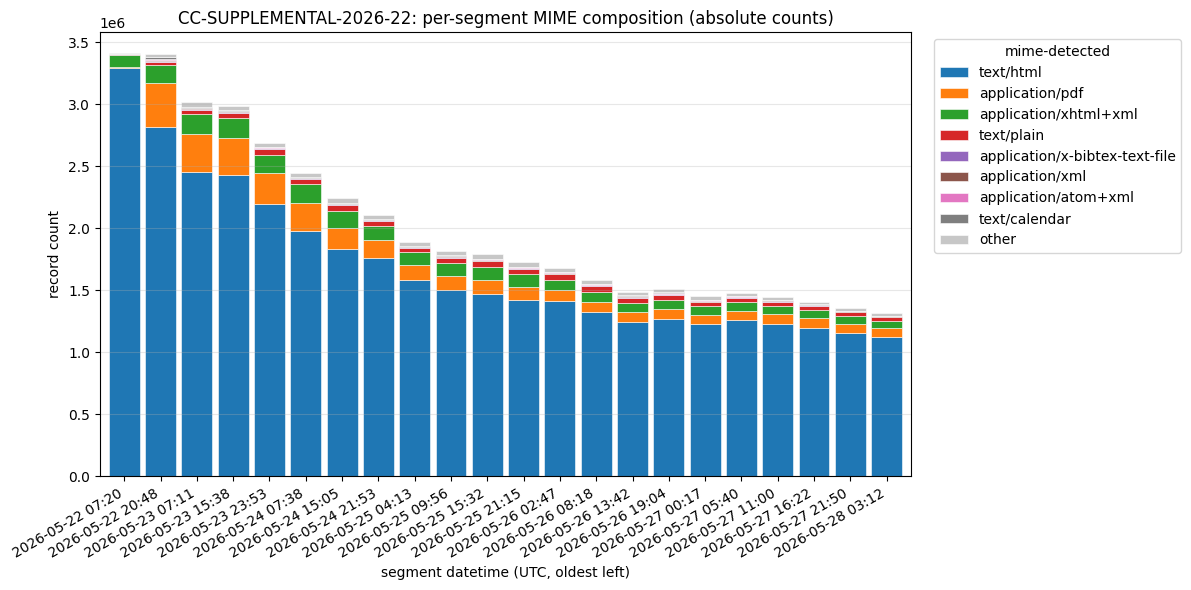

In [7]:
# Stable colour palette: tab10 + 'lightgrey' for 'other' so it visually recedes.
palette = list(plt.get_cmap("tab10").colors[:TOP_N])
colors = palette + [(0.78, 0.78, 0.78, 1.0)]

x_labels = [dt.strftime("%Y-%m-%d %H:%M") for dt in mime_df.index]

fig, ax = plt.subplots(figsize=(12, 6))
mime_df.plot.bar(stacked=True, ax=ax, color=colors, width=0.85, edgecolor="white", linewidth=0.4)
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_xlabel("segment datetime (UTC, oldest left)")
ax.set_ylabel("record count")
ax.set_title(f"{FOCUS_NAME}: per-segment MIME composition (absolute counts)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="mime-detected")
plt.tight_layout()
plt.show()


### Plot 1b &mdash; same as Plot 1 but with `text/html` excluded (linear y-axis)

`text/html` occupies ~84 % of every bar in Plot 1, which crushes every other MIME type into a sliver against the top edge. This zoomed view drops `text/html` and re-plots the remaining categories on a fresh **linear** y-axis &mdash; same data, same colours, but you can now actually read the absolute counts for `application/pdf`, `application/xhtml+xml`, `text/plain`, and the long tail.


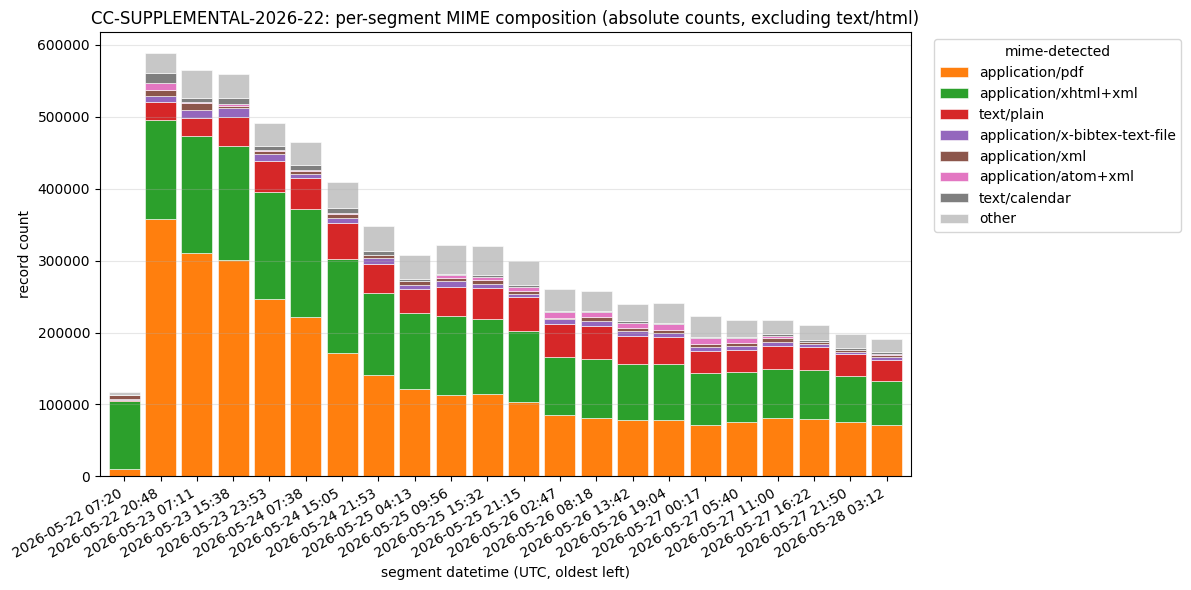

In [8]:
non_html_cols = [c for c in mime_df.columns if c != "text/html"]
non_html_df = mime_df[non_html_cols]
non_html_colors = [colors[mime_df.columns.get_loc(c)] for c in non_html_cols]

fig, ax = plt.subplots(figsize=(12, 6))
non_html_df.plot.bar(stacked=True, ax=ax, color=non_html_colors, width=0.85, edgecolor="white", linewidth=0.4)
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_xlabel("segment datetime (UTC, oldest left)")
ax.set_ylabel("record count")
ax.set_yscale("linear")  # explicit: linear, not log
ax.set_title(f"{FOCUS_NAME}: per-segment MIME composition (absolute counts, excluding text/html)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="mime-detected")
plt.tight_layout()
plt.show()


### Plot 1c &mdash; total record count per segment

Strips away MIME type entirely. One bar per segment, height = total records. Useful for spotting fetch-volume drift independently of composition (a steady decline like the one here can foreshadow an under-fetched tail).


/var/folders/cv/ww0kym4x5b98njk9g9yg9kxw0000gn/T/ipykernel_95328/1809985819.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=30, ha="right")


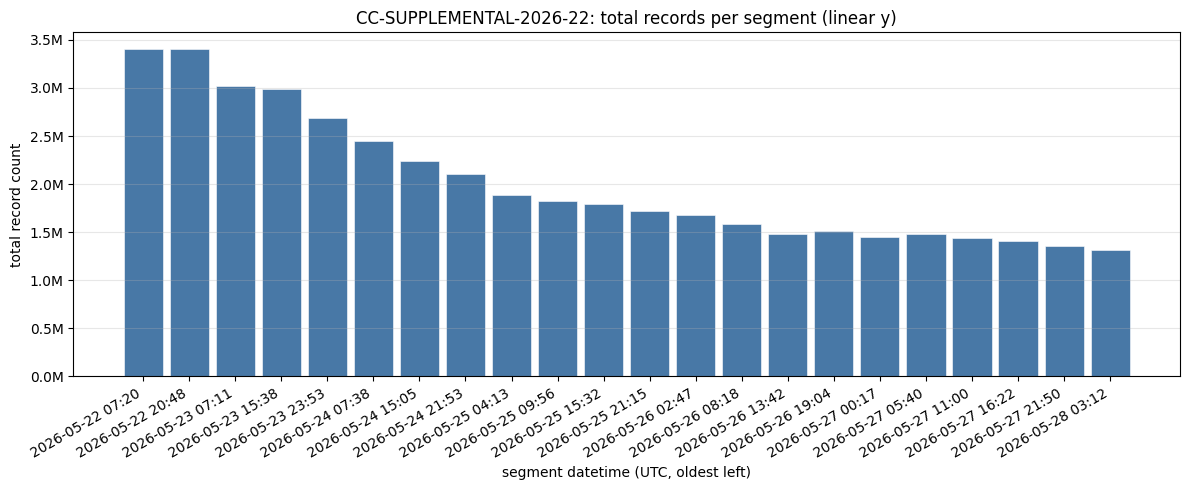

In [9]:
from matplotlib.ticker import FuncFormatter

totals_series = mime_df.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_labels, totals_series.values, width=0.85, color="#4878a6", edgecolor="white", linewidth=0.4)
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_xlabel("segment datetime (UTC, oldest left)")
ax.set_ylabel("total record count")
ax.set_yscale("linear")  # explicit: linear scale, no log
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _pos: f"{v / 1_000_000:.1f}M"))
ax.set_title(f"{FOCUS_NAME}: total records per segment (linear y)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Plot 2 &mdash; stacked bar of normalized shares (the drift plot)

Normalizing each bar to 100 % isolates **composition drift** from segment-size effects. This is the plot to read for "did the MIME mix change over time?".


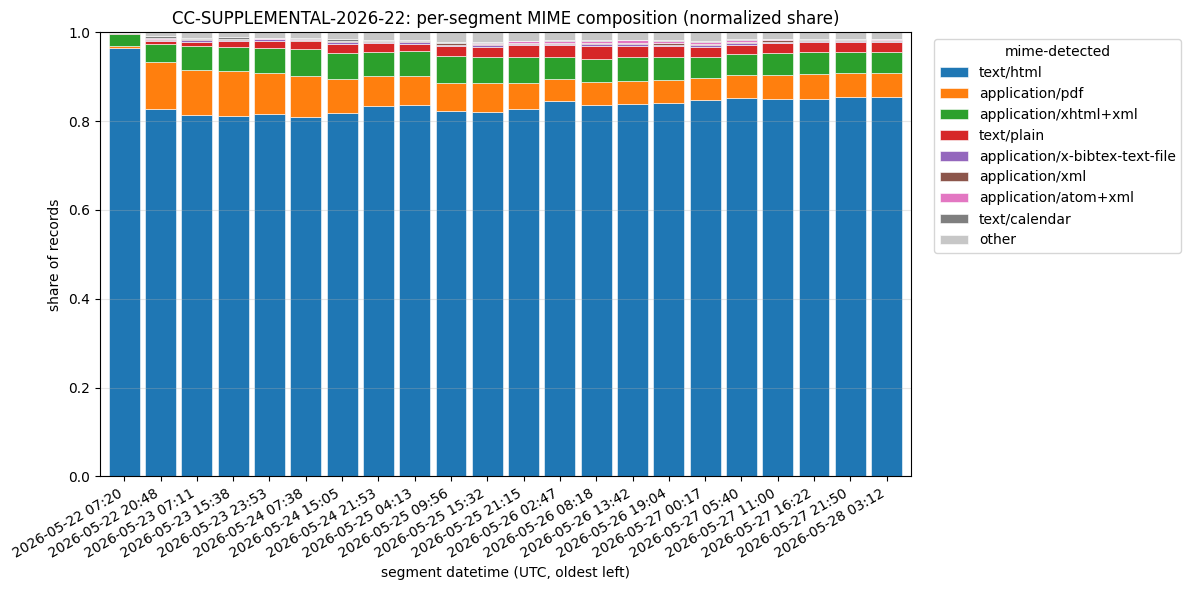

In [10]:
share_df = mime_df.div(mime_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
share_df.plot.bar(stacked=True, ax=ax, color=colors, width=0.85, edgecolor="white", linewidth=0.4)
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_xlabel("segment datetime (UTC, oldest left)")
ax.set_ylabel("share of records")
ax.set_ylim(0, 1)
ax.set_title(f"{FOCUS_NAME}: per-segment MIME composition (normalized share)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="mime-detected")
plt.tight_layout()
plt.show()


## 8. How to read these plots

- **Flat 100 % stack across the x-axis** in Plot 2 → stable MIME composition; no drift.
- **A slice growing or shrinking monotonically** → systematic drift (e.g. fetch policy change, source-list change).
- **A single bar that looks different from its neighbours** → batch-level anomaly; investigate the corresponding 14-digit segment timestamp in the fetch logs.
- **Ballooning `other`** → either real long-tail growth or `mime-detected` failing for a batch. Bump `TOP_N` to see what's hiding in `other`, or inspect the cache directly with `zcat data/cache/.../foo.csv.gz | cut -d',' -f3 | sort | uniq -c | sort -rn | head`.
- Plot 1 differs from Plot 2 → the segment had a different *size*, not a different *mix* — e.g. a partial fetch.
- Plot 1b (text/html excluded) makes absolute drift in PDF, xhtml+xml, plain text and the long tail readable — Plot 1 hides them under the html dominance.
- Plot 1c isolates *fetch volume* from composition: a steady downward trend means later segments simply contain fewer records, which is worth tracking on its own.
